# Load in Data

In [10]:
import json
from pathlib import Path
import pandas as pd
import ast
from collections import Counter
from tqdm import tqdm

In [11]:
import editdistance as ed
def find_match_word(rec_str, lexicon, pair):
    rec_str = rec_str.upper()
    match_word = ''
    match_dist = 100
    for word in lexicon: ## Find corresponding word in lexicon that has the smallest edit distance
        word = word.upper()
        ed_dist = ed.eval(rec_str, word)
        norm_ed_dist = ed_dist / max(len(word), len(rec_str))
        if norm_ed_dist < match_dist:
            match_dist = norm_ed_dist
            if pair:
                match_word = pair[word] ## Pair the word with its ground truth (may have special characters)
            else:
                match_word = word
    return match_word, match_dist

In [12]:
from shapely.geometry import Point,Polygon
### official code
def include_in_dictionary(transcription):
    #special case 's at final
    if transcription[len(transcription)-2:]=="'s" or transcription[len(transcription)-2:]=="'S":
        transcription = transcription[0:len(transcription)-2]
    #hypens at init or final of the word
    transcription = transcription.strip('-');
    specialCharacters = str("'!?.:,*\"()·[]/"); # remove special characters
    for character in specialCharacters:
        transcription = transcription.replace(character,' ')
    transcription = transcription.strip()
    if len(transcription) != len(transcription.replace(" ","")) :
        return False;
    if len(transcription) < 3:
        return False;
    notAllowed = str("×÷·");
    range1 = [ ord(u'a'), ord(u'z') ]
    range2 = [ ord(u'A'), ord(u'Z') ]
    range3 = [ ord(u'À'), ord(u'ƿ') ]
    range4 = [ ord(u'Ǆ'), ord(u'ɿ') ]
    range5 = [ ord(u'Ά'), ord(u'Ͽ') ]
    range6 = [ ord(u'-'), ord(u'-') ]
    for char in transcription :
        charCode = ord(char)
        if(notAllowed.find(char) != -1):
            return False
        valid = ( charCode>=range1[0] and charCode<=range1[1] ) or ( charCode>=range2[0] and charCode<=range2[1] ) or ( charCode>=range3[0] and charCode<=range3[1] ) or ( charCode>=range4[0] and charCode<=range4[1] ) or ( charCode>=range5[0] and charCode<=range5[1] ) or ( charCode>=range6[0] and charCode<=range6[1] )
        if valid == False:
            return False
    return True

def include_in_dictionary_transcription(transcription):
    #special case 's at final
    if transcription[len(transcription)-2:]=="'s" or transcription[len(transcription)-2:]=="'S":
        transcription = transcription[0:len(transcription)-2]
    #hypens at init or final of the word
    transcription = transcription.strip('-');            
    specialCharacters = str("'!?.:,*\"()·[]/");
    for character in specialCharacters:
        transcription = transcription.replace(character,' ')
    transcription = transcription.strip()
    return transcription

In [13]:
def filter_transcription(rec):
    import numpy as np
    if include_in_dictionary(rec) == False: ## Check if the transcription is a valid word
        rec = np.nan
    else:
        rec = include_in_dictionary_transcription(rec) ## remove special characters
    return rec
    

In [14]:
import re
IS_WORDSPOTTING = True
def count_matches_per_row(row):
    # ignore_case_symbol
    valid_symbol =  '[^A-Z^a-z^0-9^\-^\']'  ##'[^A-Z^a-z^0-9^\u4e00-\u9fa5]'
    valid_symbol = re.compile(valid_symbol)
    
    # Remove Don't care symbol    
    left_side = pd.Series([valid_symbol.sub('', i.upper()) for i in row['text'].split(' ') if valid_symbol.sub('', i.upper())])
    right_side = pd.Series([valid_symbol.sub('', i.upper()) for i in row['rec_texts'] if valid_symbol.sub('', i.upper())])
    
    #On word spotting we will filter some transcriptions with special characters
    if IS_WORDSPOTTING:
        left_side = left_side.apply(filter_transcription)
        right_side = right_side.apply(filter_transcription)
        
                    
    counter_left = Counter(left_side.dropna()) # dic
    counter_right = Counter(right_side.dropna())
    
    # 计算两侧相同元素的个数，确保每个元素只计算一次
    matches = sum((counter_left & counter_right).values())
    total = sum(counter_left.values()) #numGTcare
    numDetCare = sum(counter_right.values()) #numDetCare
    matches = sum((counter_left & counter_right).values())
    total = sum(counter_left.values())
    total_char = sum([len(word)*freq for word,freq in counter_left.items()])
    match_char = sum([len(word)*freq for word,freq in (counter_left & counter_right).items()])
    numDetCare_char = sum([len(word)*freq for word,freq in counter_right.items()])
    
    return [total, matches, numDetCare, total_char, match_char,numDetCare_char]


In [15]:
filter_df = pd.read_csv('../../data/human/SelectedFilter.csv')

In [16]:
def matrix_cal(row):
    precision = 0 if float(row['match'])==0 else float(row['match']) / row['numDetCare']
    recall = 0 if float(row['match'])==0 else float(row['match']) / row['numGTcare']
    f1 = 0 if (precision + recall==0) else 2.0 * precision * recall / (precision + recall)
    
    precision_char = 0 if float(row['match_char'])==0 else float(row['match_char']) / row['numDetCare_char']
    recall_char = 0 if float(row['match_char'])==0 else float(row['match_char']) / row['numGTcare_char']
    f1_char = 0 if (precision_char + recall_char==0) else 2.0 * precision_char * recall_char / (precision_char + recall_char)
    return f1
    
    

In [17]:
output_dir = Path("../../filtered/totaltext")
gt_dir = Path("../../data/totaltext")
files = list(output_dir.rglob('*.*'))
result_li = []
# Load the ground truth COCO JSON (annotations only or full dataset)
with open(gt_dir/"anno.json", "r") as f:
    ground_truth = json.load(f)
# Here we assume ground_truth has a key "annotations"
gt_annotations = ground_truth.get("annotations", [])
img_info = ground_truth.get("images", [])

for model_file in tqdm(files, total=len(files), desc="Rinse model outputs"):
    # Load the model output JSON (replace with your file or object)
    # model_file = output_dir/ "gpt4o.json"
    model_name = model_file.stem
    with open(model_file, "r") as f:
        model_output = json.load(f)

    # Create lookup dictionaries for ground truth annotations and image info by image_id.
    # If there are multiple ground truth annotations per image, you might need to store a list.
    gt_by_chart = {}
    for info, ann in zip(img_info, gt_annotations):
        id = ann["id"]
        full = {}
        full["image_id"] = ann["image_id"]
        full["file_name"] = info["file_name"]
        full["Filter_no"] = info["Filter_no"]
        full["text"] = ann["caption"]
        gt_by_chart.setdefault(id, full)
        
    
    # Now iterate through the model outputs and match with ground truth and image info
    full_out = {}
    for output_item in model_output:
        image_id = output_item["image_id"]
        
        # Optionally, if your model output's "rec_texts" is a string representation of a list,
        # convert it to an actual list.
        rec_texts_str = output_item.get("rec_texts", "")
        try:
            rec_texts = ast.literal_eval(rec_texts_str)
        except Exception:
            rec_texts = rec_texts_str
        output_item["rec_texts"] = rec_texts

        # Retrieve corresponding ground truth annotations (if any)
        gt_matches = gt_by_chart.get(image_id, {})
        chart_no = Path(gt_matches.get("file_name", "")).stem.split("/")[-1]
        full_out[image_id] = gt_matches
        full_out[image_id]["rec_texts"] = rec_texts
        full_out[image_id]["chart_no"] = chart_no

        
        
    df = pd.DataFrame(full_out.values())
    df = pd.merge(df, filter_df, on='Filter_no', how='inner')

    df[['numGTcare','match', 'numDetCare','numGTcare_char', 'match_char','numDetCare_char']] = df.apply(lambda row: count_matches_per_row(row), axis=1).apply(pd.Series)
    df[['f1']] = df.apply(lambda x: matrix_cal(x), axis=1).apply(pd.Series)
    
    group_sum = df.copy()
    # group_sum.columns = ['chart_no', 'a', 'b', 'VA', 'CS', 'Cond','f1']
    group_sum = group_sum.groupby(['a', 'b', 'VA', 'CS', 'Cond']).apply(lambda x: x['f1'].mean()).reset_index()
    group_sum.columns = ['a', 'b', 'VA', 'CS', 'Cond',model_name]
    result_li.append(group_sum)


Rinse model outputs:   0%|          | 0/10 [00:00<?, ?it/s]/tmp/ipykernel_61765/1216727008.py:63: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  group_sum = group_sum.groupby(['a', 'b', 'VA', 'CS', 'Cond']).apply(lambda x: x['f1'].mean()).reset_index()
Rinse model outputs:  10%|█         | 1/10 [00:00<00:01,  7.28it/s]/tmp/ipykernel_61765/1216727008.py:63: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  group_

In [18]:
from functools import reduce
summary_dir = Path("../../data/summary")
reduce(lambda left, right: pd.merge(left, right, on=['a', 'b', 'VA', 'CS', 'Cond']), result_li).to_csv(summary_dir/'totaltext.csv', index=False)

In [93]:
import pandas as pd
df1 = reduce(lambda left, right: pd.merge(left, right, on=['a', 'b', 'VA', 'CS', 'Cond']), result_li)
df2 = pd.read_csv(summary_dir/'ScenetTextSummary.csv')
df2 = df2.pivot(index=['Filter_no','a','b','Cond','Expected_Change'], columns='Model')['f1'].reset_index()
df2.columns = [''.join(map(str, col)).strip() for col in df2.columns.values]
df2['Expected_Change'] = df2['Expected_Change'] - 0.24
df2.rename(columns={'Expected_Change':'Expected'}, inplace=True)
df2.drop(columns=['gpt4o','Cond'], inplace=True)

df_human = pd.read_csv('../../data/human/human_totaltext_acuity.csv')

In [94]:
final_df = pd.merge(pd.merge(df1, df_human, on=['a', 'b'],how='left'), df2, on=['a', 'b'], how='left')
models = ['human', 'human_err', 'SeeingAI','gpt4o', 'gpt4o_mini', 'gemini_15_flash',
       'gemini_15_pro', 'gemini_2_flash', 'claude3_7_sonnet', 'claude3_5_haiku',
       'cogvlm','Qwen2.5-VL-3B-Instruct', 'Qwen2.5-VL-7B-Instruct', 'Qwen2.5-VL-32B-Instruct',
       'db_maerecB', 'db_maerecS', 'dbpp_maerecB', 'dbpp_maerecS','spts', 'google']
final_df = final_df[['a', 'b', 'VA', 'CS', 'Cond', 'Expected'] + models]
final_df.to_csv(summary_dir/'totaltext_combined_0331.csv', index=False)

# Figure

In [162]:
final_df_fig = pd.read_csv('../../data/summary/totaltext_combined_0331.csv')#final_df.copy()
models = ['human','SeeingAI', 'gpt4o',
       'gpt4o_mini', 'gemini_15_flash', 'gemini_15_pro', 'gemini_2_flash',
       'claude3_7_sonnet', 'claude3_5_haiku', 'cogvlm',
       'Qwen2.5-VL-3B-Instruct', 'Qwen2.5-VL-7B-Instruct',
       'Qwen2.5-VL-32B-Instruct', 'db_maerecB', 'db_maerecS', 'dbpp_maerecB',
       'dbpp_maerecS', 'spts', 'google']

final_df_fig[['Expected']] =  final_df_fig[['Expected']]  - final_df_fig.loc[15,['Expected']]
final_df_fig.loc[final_df_fig['Cond']=='Original', 'Cond'] = 'Combined'

model_name_dict = {'human':'Human','SeeingAI':'SeeingAI', 'gpt4o':'GPT4O', 'gpt4o_mini':'GPT4O Mini', 
                   'gemini_15_flash':'Gemini-1.5 Flash','gemini_15_pro':'Gemini-1.5 Pro', 'gemini_2_flash':'Gemini-2 Flash', 
                   'claude3_7_sonnet':'Claude3.7 Sonnet', 'claude3_5_haiku':'Claude3.5 Haiku','cogvlm':'CogAgent',
                   'Qwen2.5-VL-3B-Instruct':'Qwen2.5-VL-3B', 'Qwen2.5-VL-7B-Instruct':'Qwen2.5-VL-7B', 'Qwen2.5-VL-32B-Instruct':'Qwen2.5-VL-32B',
                   'maerec':'DBNet++ & MaeRec','spts':'SPTS v2', 'ppocr':'PPOCR', 'azure':'Azure', 'google':'Google Vision'}
final_df_fig.rename(columns=model_name_dict, inplace=True)
models = [model_name_dict[i] for i in models if i in model_name_dict]

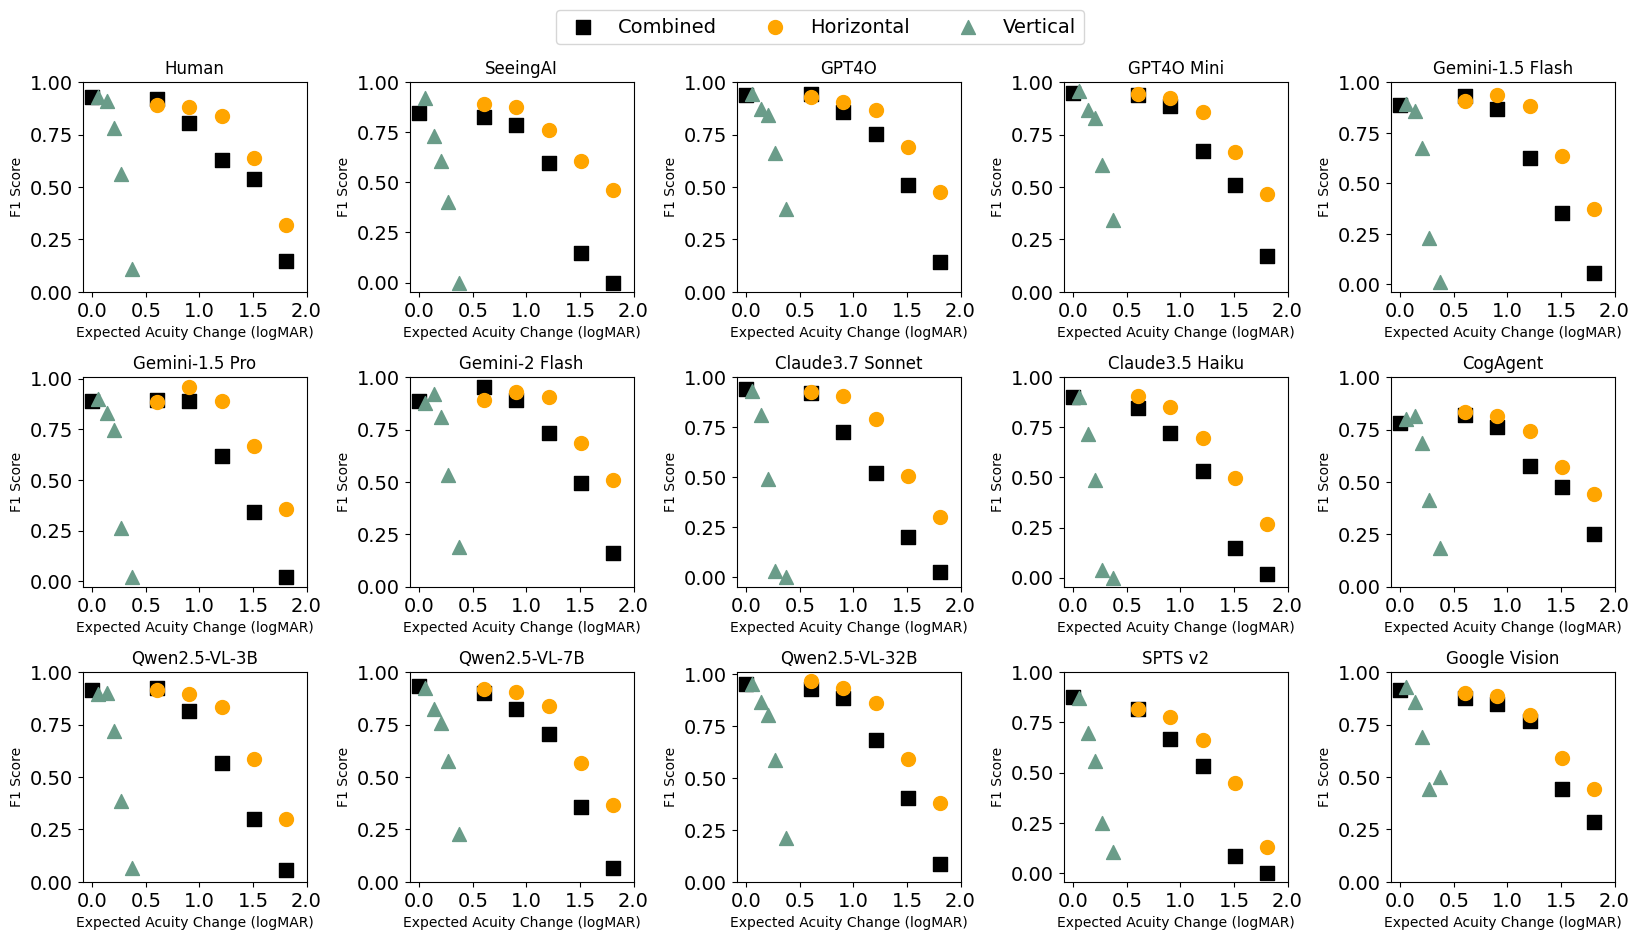

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import math
import numpy as np

# Define a function to choose marker based on condition
def get_marker(cond):
    if cond == 'Horizontal':
        return 'o'  # hollow square
    elif cond == 'Vertical':
        return '^'  # hollow triangle
    else:
        return 's'  # hollow circle

# Create a color palette for unique conditions
unique_conditions = final_df_fig['Cond'].unique()
# palette = sns.color_palette("viridis", len(unique_conditions))
# color_mapping = {cond: palette[i] for i, cond in enumerate(unique_conditions)}
colors = ['orange', 'black', '#6A9C89', 'black']
# Create the mapping
color_mapping = {cond: color for cond, color in zip(unique_conditions, colors)}

# Define a function to plot a scatter plot on a given axis for a specified model column
def plot_scatter(ax, model_col, df):
    # Plot each group (by Cond) separately to assign markers and colors
    for cond, group in df.groupby('Cond'):
        marker = get_marker(cond)
        ax.scatter(
            group['Expected'],
            group[model_col],
            label=cond,
            marker=marker,
            facecolors=color_mapping[cond],  # makes marker hollow
            edgecolors=color_mapping[cond],
            s=100  # marker size
        )
        # if model_col == 'human':
        #     ax.fill_between(pd.to_numeric(group['Expected'], errors='coerce'), 
        #                     pd.to_numeric(group[model_col], errors='coerce') - group['human_err'], 
        #                     pd.to_numeric(group[model_col], errors='coerce') + group['human_err'], 
        #                     color='red', alpha=0.05)
    
    # Add a dashed diagonal line that spans the range of the data
    # x_vals = df['Expected']
    # y_vals = df[model_col]
    # overall_min = min(x_vals.min(), y_vals.min())
    # overall_max = max(x_vals.max(), y_vals.max())
    # ax.plot([overall_min, overall_max], [overall_min, overall_max],
    #         linestyle='--', color='grey')
    
    # Set labels, title and legend
    ax.set_xlabel("Expected Acuity Change (logMAR)")
    ax.set_ylabel("F1 Score")
    ax.set_xticks(np.arange(0, 2.1, 0.5))
    ax.set_yticks(np.arange(0, 1.1, 0.25))
    ax.set_title(f"{model_col}")
    # ax.tick_params(axis='both', labelsize=12)
    plt.setp(ax.get_xticklabels(), fontsize=14)
    plt.setp(ax.get_yticklabels(), fontsize=14)
    # ax.legend()

# List of models to plot (include 'human' and other models)
# models = ['human','SeeingAI' ,'gpt4o', 'gpt4o_mini', 'gemini_15_flash',
#        'gemini_15_pro', 'gemini_2_flash', 'claude3_7_sonnet', 'claude3_5_haiku',
#        'qwen', 'maerec','spts', 'ppocr', 'azure', 'google']

# Determine subplot grid layout; here we choose 2 columns
num_models = len(models)
ncols = 5
nrows = math.ceil(num_models / ncols)
nrows = math.ceil(num_models / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(3.3 * ncols, 3 * nrows))
# If there's only one subplot, axes is not an array; make it a list for consistency.
if num_models == 1:
    axes = [axes]
else:
    axes = axes.flatten()

# Plot each model in its corresponding subplot
for i, model in enumerate(models):
    plot_scatter(axes[i], model, final_df_fig)

# Remove any extra subplots if the grid has more axes than models
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])



handles, labels = axes.flatten()[0].get_legend_handles_labels()

# Place a common legend outside the figure. Here, loc='upper center' puts it at the top,
# and bbox_to_anchor adjusts its position. Adjust ncol for number of columns in legend.
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 1.05), ncol=3, fontsize=14)
plt.tight_layout()

plt.savefig('../../figure/totaltext.png', dpi=300)

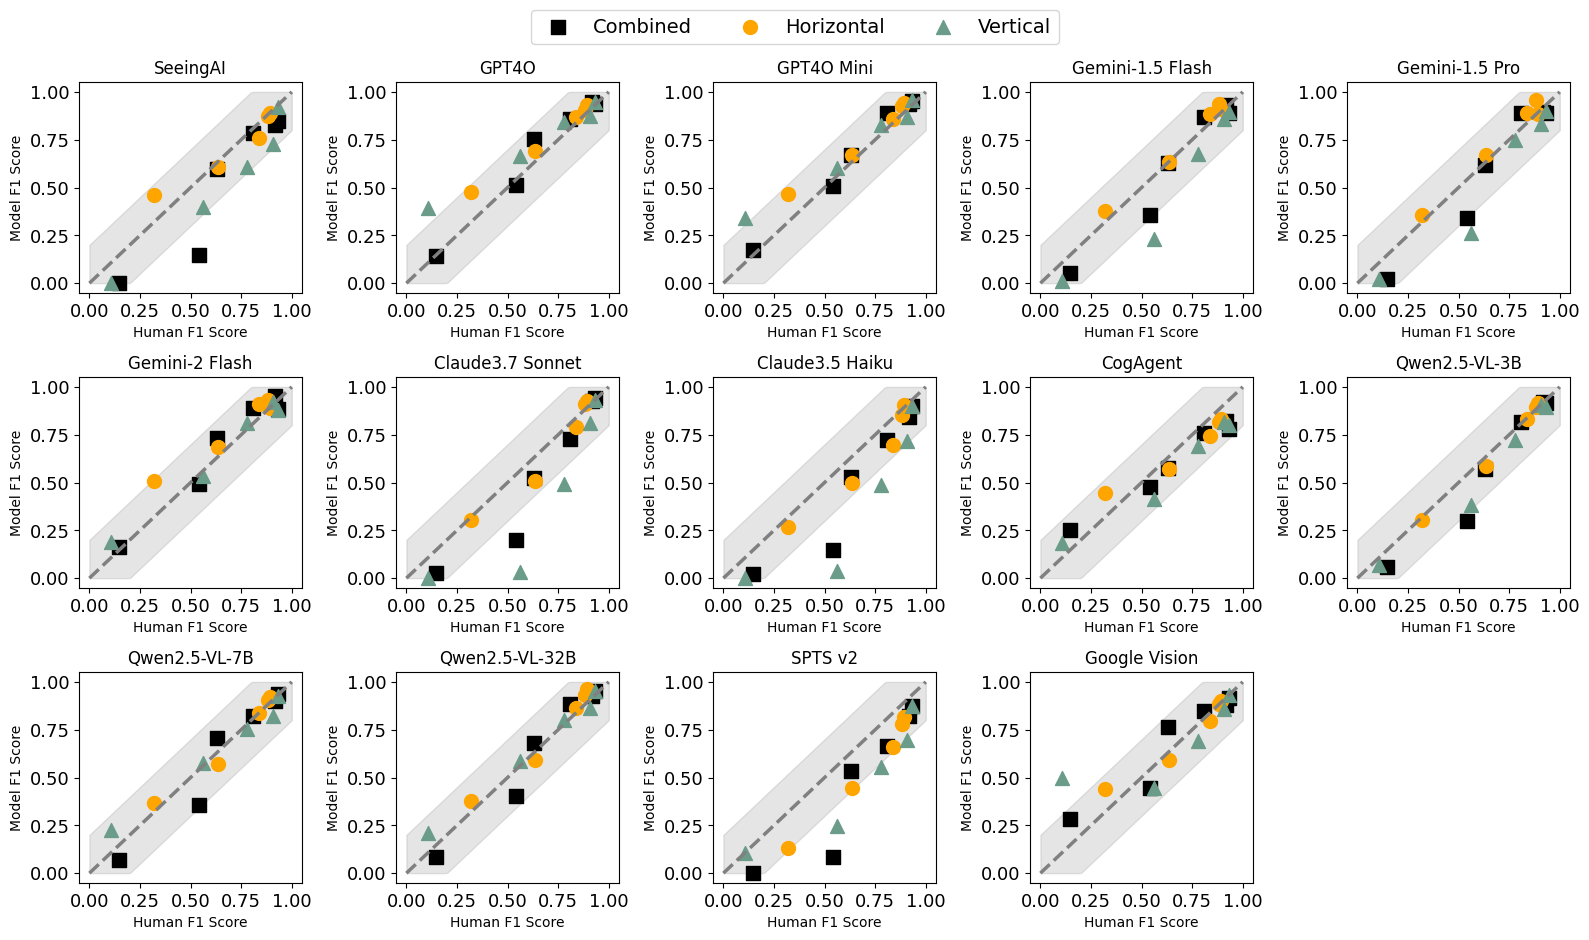

In [176]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import math


# Create a color palette for unique conditions
unique_conditions = final_df_fig['Cond'].unique()
# palette = sns.color_palette("viridis", len(unique_conditions))
# color_mapping = {cond: palette[i] for i, cond in enumerate(unique_conditions)}
colors = ['orange', 'black', '#6A9C89', 'black']
# Create the mapping
color_mapping = {cond: color for cond, color in zip(unique_conditions, colors)}


# Define a function to plot a scatter plot on a given axis for a specified model column
def plot_scatter(ax, model_col, df):
    # Add a dashed diagonal line that spans the range of the data
    x_vals = df['Human']
    y_vals = df[model_col]
    overall_min = 0 #min(x_vals.min(), y_vals.min())
    overall_max = 1.0 #max(x_vals.max(), y_vals.max())
    ax.plot([overall_min, overall_max], [overall_min, overall_max],
            linestyle='--', color='grey', linewidth=2.5)
    x = np.linspace(overall_min, overall_max, 100)
    # Fill the area between y = x - 0.2 and y = x + 0.2
    lower_bound = np.clip(x - 0.2, overall_min, overall_max)
    upper_bound = np.clip(x + 0.2, overall_min, overall_max)

    # Fill the area between the clipped bounds
    ax.fill_between(x, lower_bound, upper_bound, color='grey', alpha=0.2)

    # Plot each group (by Cond) separately to assign markers and colors
    for cond, group in df.groupby('Cond'):
        marker = get_marker(cond)
        ax.scatter(
            group['Human'],
            group[model_col],
            label=cond,
            marker=marker,
            facecolors=color_mapping[cond],  # makes marker hollow
            edgecolors=color_mapping[cond],
            s=100  # marker size
        )
    
    # # Add a dashed diagonal line that spans the range of the data
    # x_vals = df['Human']
    # y_vals = df[model_col]
    # overall_min = min(x_vals.min(), y_vals.min()) - 0.1
    # overall_max = max(x_vals.max(), y_vals.max()) + 0.1
    # ax.plot([overall_min, overall_max], [overall_min, overall_max],
    #         linestyle='--', color='grey')
    
    # Set labels, title and legend
    ax.set_xlabel("Human F1 Score")
    ax.set_ylabel("Model F1 Score")
    ticks = [0, 0.25, 0.5, 0.75, 1]
    ax.set_xticks(ticks)
    ax.set_yticks(ticks)
    ax.set_title(f"{model_col}")
    plt.setp(ax.get_xticklabels(), fontsize=13)
    plt.setp(ax.get_yticklabels(), fontsize=13)
    # ax.legend()

# List of models to plot (include 'human' and other models)
# models = ['human','SeeingAI' ,'gpt4o', 'gpt4o_mini', 'gemini_15_flash',
#        'gemini_15_pro', 'gemini_2_flash', 'claude3_7_sonnet', 'claude3_5_haiku',
#        'qwen', 'maerec','spts', 'ppocr', 'azure', 'google']

# Determine subplot grid layout; here we choose 2 columns
num_models = len(models) -1
ncols = 5
nrows = math.ceil(num_models / ncols)
nrows = math.ceil(num_models / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(3.2 * ncols, 3 * nrows))
# If there's only one subplot, axes is not an array; make it a list for consistency.
if num_models == 1:
    axes = [axes]
else:
    axes = axes.flatten()

# Plot each model in its corresponding subplot
for i, model in enumerate(models[1:]):
    plot_scatter(axes[i], model, final_df_fig)

# Remove any extra subplots if the grid has more axes than models
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])
    
# Get handles and labels from one of the axes (or combine them if different)
handles, labels = axes.flatten()[0].get_legend_handles_labels()

# Place a common legend outside the figure. Here, loc='upper center' puts it at the top,
# and bbox_to_anchor adjusts its position. Adjust ncol for number of columns in legend.
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 1.05), ncol=3, fontsize=14)

plt.tight_layout()
plt.savefig('../../figure/totaltext_human_model.png', dpi=300)


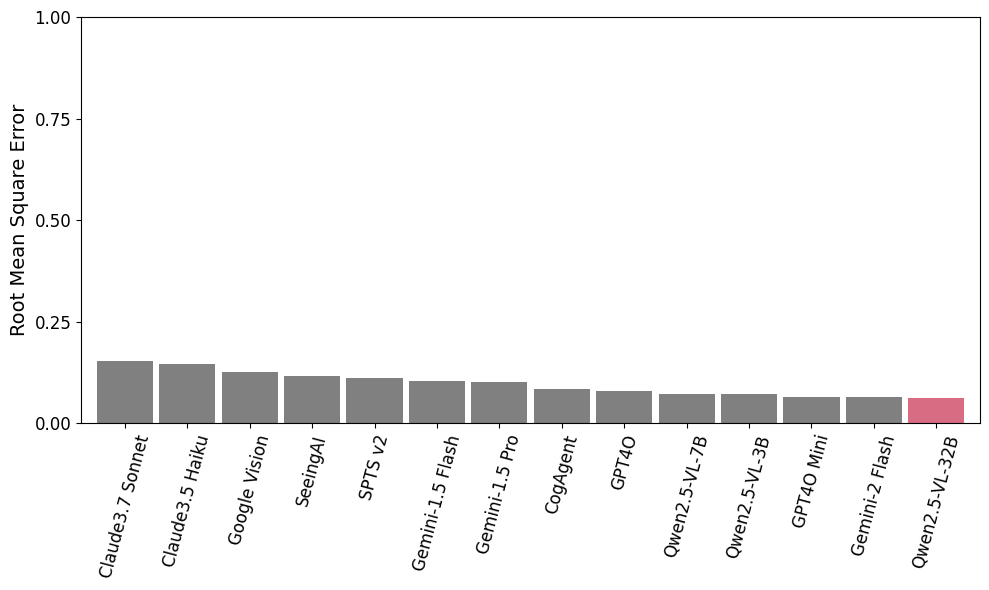

In [175]:
std_values = final_df_fig[models].sub(final_df_fig['Human'], axis=0).std()
std_values.drop(index=['Human'], inplace=True)
# Identify the model with the smallest std
min_model = std_values.idxmin()

# Create a color list: red for the model with the smallest std; use a nice color (e.g. 'skyblue') for others.
colors = ['#D76C82' if model == min_model else 'gray' for model in std_values.index]

# Optional: sort the values for a prettier display (and sort colors accordingly)
std_values_sorted = std_values.sort_values(ascending=False)
colors_sorted = [colors[std_values.index.get_loc(model)] for model in std_values_sorted.index]
# Create the plot
plt.figure(figsize=(10, 6))
std_values_sorted.plot(kind='bar', color=colors_sorted, edgecolor='none', width=0.9)

# Customize axis labels, title, and tick parameters
# plt.xlabel("Model", fontsize=14, fontweight='bold')
plt.ylabel("Root Mean Square Error", fontsize=14)
plt.yticks(np.arange(0,1.01,0.25),fontsize=12)
plt.xticks(rotation=75, fontsize=12)
plt.tight_layout()

plt.savefig('../../figure/totaltext_rmse.png', dpi=300)